<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/exercises/05_rocket_trajopt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trajectory Optimization with SQP: Rocket System

In this exercise, you'll implement and explore **Sequential Quadratic Programming (SQP)** to solve nonlinear trajectory optimization problems.

We consider a simplified rocket modeled after an inverted cart-pole with thrust vectoring capabilities:
- The rocket is represented as an **inverted pendulum** mounted on a movable base.
- The system consists of:
    - A thruster/base with mass $m_t$ (the "cart")
    - A rocket body with mass $m_b$ and length $\ell$ (the "pole")
    - The rocket can move freely in 2D and rotate about its base.

**State Vector**: $x = [p_x, p_z, \theta, \dot{p}_x, \dot{p}_z, \dot{\theta}]^T$, where:
- $(p_x, p_z)$: position of the rocket base
- $\theta$: angle from vertical (upright is $\theta = 0$), with clockwise positive
- $(\dot{p}_x, \dot{p}_z)$: velocities of the base
- $\omega = \dot{\theta}$: angular velocity of the rocket body

**Control Input**: $u = [T_{\text{base},x}, T_{\text{base},z}, T_{\text{nose},x}]^T$, representing thrust at the rocket base and nose.

**Objective**: Starting from a high altitude with initial velocity, the task is to **land the rocket softly** on a designated landing pad, satisfying:
- Low final velocities
- Upright orientation ($\theta \approx 0$)
- Accurate landing pad placement

**Constraints**:
1. **Thrust Limits**: Both upper and lower bounds on horizontal and vertical thrusts
2. **Landing Zone**: Final position must be within the designated landing region
3. **Obstacle Avoidance**: The trajectory must avoid specified circular no-fly zones


In [615]:
import functools
import os
import warnings
from typing import Callable, Dict, List

import cvxpy as cp
import dynamaxsys
import equinox as eqx

import jax
import jax.numpy as jnp
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

Some helper functions for plotting and simulation.
Take a look to get a sense of what each function is doing, and run cell as is.

In [616]:
# helper functions for plotting
def plot_rocket_trajectory(states, controls, lower, upper):
    """
    Plots rocket state and control trajectories.

    Args:
        states: Array of shape (n_steps+1, state_dim)
        controls: Array of shape (n_steps, control_dim)
        lower: np.array of shape (control_dim,) — lower limits for controls
        upper: np.array of shape (control_dim,) — upper limits for controls
    """
    n_steps = controls.shape[-2]
    if len(states.shape) == 2:
        alpha = 1.0
    else:
        alpha = 0.4
    fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex=True)

    # Position
    axs[0, 0].plot(states[..., :, 0].T, color="C0", alpha=alpha)
    axs[0, 0].plot(states[..., :, 1].T, color="C1", alpha=alpha)
    axs[0, 0].set_ylabel("Position (m)")
    leg = axs[0, 0].legend(["p_x (horizontal)", "p_z (altitude)"])
    # Set legend line color to match line color (C0, C1)
    for i, line in enumerate(leg.get_lines()):
        line.set_color(f"C{i}")
    axs[0, 0].grid(True)

    # Angle
    axs[1, 0].plot(states[..., :, 2].T, color="C0", alpha=alpha)
    axs[1, 0].set_ylabel("Angle (rad)")
    axs[1, 0].legend(["theta"])
    axs[1, 0].grid(True)

    # Velocities
    axs[0, 1].plot(states[..., :, 3].T, color="C0", alpha=alpha)
    axs[0, 1].plot(states[..., :, 4].T, color="C1", alpha=alpha)
    axs[0, 1].set_ylabel("Velocity (m/s)")
    leg = axs[0, 1].legend(["v_x", "v_z"])
    for i, line in enumerate(leg.get_lines()):
        line.set_color(f"C{i}")
    axs[0, 1].grid(True)

    # Controls
    axs[1, 1].plot(controls[..., :, 0].T, color="C0", alpha=alpha)
    axs[1, 1].plot(controls[..., :, 1].T, color="C1", alpha=alpha)
    axs[1, 1].plot(controls[..., :, 2].T, color="C2", alpha=alpha)
    leg = axs[1, 1].legend(["T_x", "T_z", "T_nose"])
    for i, line in enumerate(leg.get_lines()):
        line.set_color(f"C{i}")

    axs[1, 1].hlines(lower[0], 0, n_steps, color="C0", linestyle="--")
    axs[1, 1].hlines(upper[0], 0, n_steps, color="C0", linestyle="--")

    axs[1, 1].hlines(lower[1], 0, n_steps, color="C1", linestyle="--")
    axs[1, 1].hlines(upper[1], 0, n_steps, color="C1", linestyle="--")

    axs[1, 1].hlines(lower[2], 0, n_steps, color="C2", linestyle="--")
    axs[1, 1].hlines(upper[2], 0, n_steps, color="C2", linestyle="--")

    axs[1, 1].set_ylabel("Thrust (N)")
    axs[1, 1].set_xlabel("Time step")

    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()


def plot_rocket(
    ax: plt.Axes,
    state: jnp.ndarray,
    control: jnp.ndarray | None = None,
    color: str = "C0",
    label: str | None = None,
    rocket_length: float = 2.0,
    thrust_limit: List[float] = [200.0, 300.0, 100.0],
):
    """
    Draw a simple rocket at the specified state, with optional thrust vectors at base and nose.

    Args:
      ax: matplotlib axis
      state: array-like of shape (6,) [x, z, theta, vx, vz, omega]
      control: array-like of shape (,), assumed [thrust, gimbal_angle] or [Tx, Tz], etc.
      color: color for rocket body
      label: optional label for the rocket
      rocket_length: length of the rocket
    """
    x, z, theta = float(state[0]), float(state[1]), float(state[2])

    # Compute end points of rocket body in world frame
    # Rocket body from (-L/2, 0) to (+L/2, 0) in body frame
    dx = rocket_length * np.sin(theta)
    dz = rocket_length * np.cos(theta)

    x_base = x
    z_base = z
    x_nose = x + dx
    z_nose = z + dz

    # Draw main body
    ax.plot(
        [x_base, x_nose],
        [z_base, z_nose],
        color=color,
        linewidth=6,
        solid_capstyle="round",
        label=label,
    )

    # Draw thrust vectors at base and nose if control is provided
    if control is not None:
        T_base_x, T_base_z, T_nose_x = control
        thrust_scale = 5.0  # scaling factor for vector length

        ax.arrow(
            x_base,
            z_base,
            thrust_scale * T_base_x / thrust_limit[0],
            thrust_scale * T_base_z / thrust_limit[1],
            head_width=0.06,
            head_length=0.13,
            fc="crimson",
            ec="crimson",
            alpha=0.6,
            length_includes_head=True,
            zorder=5,
        )
        ax.arrow(
            x_nose,
            z_nose,
            thrust_scale * T_nose_x / thrust_limit[2],
            0,
            head_width=0.06,
            head_length=0.13,
            fc="crimson",
            ec="crimson",
            alpha=0.6,
            length_includes_head=True,
            zorder=5,
        )

    # Draw ground
    ax.hlines(0, -3, 3, color="k", linewidth=2, zorder=0)


def animate_rocket_trajectory(
    states,
    controls=None,
    interval=50,
    ax=None,
    save_path=None,
    color="C0",
    label=None,
    rocket_length=2.0,
    thrust_limit: List[float] = [200.0, 300.0, 100.0],
    obstacle_center: tuple = None,
    obstacle_radius: float = None,
    obstacle_color: str = "gray",
    obstacle_alpha: float = 0.4,
):
    """
    Animate rocket trajectory and pose over time, output as HTML if possible.
    Args:
      states: array-like, shape [N,6]
      controls: array-like, shape [N,...], optional
      interval: ms between frames (default 50)
      ax: optional matplotlib axis
      save_path: optional, if provided save as .mp4, .gif, or .html
      obstacle_center: (x, z) tuple for obstacle center (optional)
      obstacle_radius: float, radius of the obstacle (optional)
      obstacle_color: color spec for obstacle (default 'gray')
      obstacle_alpha: alpha blending value for obstacle (default 0.4)
    """

    states = np.asarray(states)
    if controls is not None:
        controls = np.asarray(controls)
    N = len(states)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 8))
    else:
        fig = ax.figure

    xs = states[:, 0]
    zs = states[:, 1]

    # Draw ground
    ground_x = [xs.min() - 1, xs.max() + 1]
    ground_z = [0, 0]
    ax.plot(ground_x, ground_z, "k-", linewidth=2)

    # Draw circular obstacle if specified
    obstacle_artist = None
    if obstacle_center is not None and obstacle_radius is not None:
        from matplotlib.patches import Circle

        ox, oz = obstacle_center
        obstacle_artist = Circle(
            (ox, oz),
            obstacle_radius,
            color=obstacle_color,
            alpha=obstacle_alpha,
            zorder=1,
        )
        ax.add_patch(obstacle_artist)

    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("z [m]")
    ax.set_title("Rocket landing trajectory")

    # Main trajectory (background)
    (traj_line,) = ax.plot([], [], "k--", alpha=0.4)

    rocket_artists = []

    def init():
        traj_line.set_data([], [])
        for artist in rocket_artists:
            artist.remove()
        rocket_artists.clear()
        return [traj_line] + ([obstacle_artist] if obstacle_artist is not None else [])

    def animate(i):
        # Update trajectory line
        traj_line.set_data(xs[: i + 1], zs[: i + 1])
        # Clear previous rockets
        for artist in rocket_artists:
            artist.remove()
        rocket_artists.clear()
        # Draw rocket at current state
        try:
            plot_rocket(
                ax,
                states[i],
                controls[i],
                color=color,
                label=label,
                rocket_length=rocket_length,
                thrust_limit=thrust_limit,
            )
        except Exception:
            plot_rocket(
                ax,
                states[i],
                color=color,
                label=label,
                rocket_length=rocket_length,
                thrust_limit=thrust_limit,
            )
        # Collect all new artists
        for child in ax.get_children():
            if isinstance(child, (plt.Line2D, plt.Polygon)) and child not in [
                traj_line
            ]:
                rocket_artists.append(child)
        output = [traj_line] + rocket_artists
        if obstacle_artist is not None:
            output.append(obstacle_artist)
        return output

    ani = animation.FuncAnimation(
        fig,
        animate,
        frames=N,
        init_func=init,
        blit=False,
        interval=interval,
        repeat=False,
    )

    # HTML output by default if not saving as a file
    if save_path is not None:
        ext = os.path.splitext(save_path)[1].lower()
        if ext == ".gif":
            ani.save(save_path, writer="pillow")
        display(HTML(ani.to_jshtml()))
        plt.close(fig)
    else:
        display(HTML(ani.to_jshtml()))
        plt.close(fig)


In [617]:
# helper functions for simulation
@eqx.filter_jit
def closed_loop_sim(
    dynamics_discrete: dynamaxsys.Dynamics,
    initial_state: jnp.ndarray,
    controller: Callable[[jnp.ndarray], jnp.ndarray],
    sim_steps: int,
):
    """Simulate the closed-loop system given a closed-loop controller using jax.lax.scan"""

    def step_fn(state, _):
        control = controller(state)
        next_state = dynamics_discrete(state, control)
        return next_state, (next_state, control)

    # Dummy scan inputs as we need sim_steps steps
    dummy_inputs = jnp.arange(sim_steps)
    final_state, (all_states, all_controls) = jax.lax.scan(
        step_fn, initial_state, dummy_inputs
    )

    # Include the initial state
    states = jnp.concatenate([initial_state[None], all_states], axis=0)
    return states, all_controls


@eqx.filter_jit
def open_loop_sim(
    dynamics_discrete: dynamaxsys.Dynamics,
    initial_state: jnp.ndarray,
    controls: jnp.ndarray,
):
    """Simulate the open-loop system given a dynamics model using jax.lax.scan"""

    def step_fn(state, control):
        next_state = dynamics_discrete(state, control)
        return next_state, next_state

    # Run scan
    final_state, all_next_states = jax.lax.scan(step_fn, initial_state, controls)

    # Concatenate initial state at the front
    states = jnp.concatenate([initial_state[None], all_next_states], axis=0)
    return states


### (a) Implement the system dynamics

In this part, you will use the `dynamaxsys` package to implement a custom dynamics class that models the rocket dynamics.

The rocket is modeled similarly to an inverted cart-pole system, but with modifications that allow forces to act in both the horizontal and vertical directions, as well as additional thrusters that generate moments for stabilization.

The full derivation of the rocket dynamics—based on the Euler-Lagrange formalism—can be found on the course website under the `Miscellaneous` tab. If you are not yet familiar with Euler-Lagrange equations, don't worry! You can rely on the final state-space equations at the end of the derivation for your implementation. (But we encourage you to read up on the approach, since it's a powerful technique!)

Your goal here is to implement the continuous-time dynamics according to those equations, encapsulated in a class that inherits from `dynamaxsys.Dynamics`.

In [618]:
class RocketDynamics(dynamaxsys.Dynamics):
    """Rocket dynamics class.
    Refer to 05a-rocket-derivation.md for the derivation of the dynamics.
    """

    def __init__(self, params: Dict[str, float]):
        """
        Initialize the rocket dynamics class.
        Args:
            params: Dictionary containing the rocket parameters.
        """
        state_dim = 6
        control_dim = 3

        def rocket_ode(
            states: jnp.ndarray,
            controls: jnp.ndarray,
            disturbance: jnp.ndarray = None,  # need to provide disturbance for the dynamics class, but not used in this notebook
            time: float = 0.0,  # need to provide time for the dynamics class, but not used in this notebook
        ):
            mass_thruster = params["mass_thruster"]
            mass_body = params["mass_body"]
            length = params["length"]
            gravity = params["gravity"]
            _, _, theta, v_x, v_z, omega = states

            # TODO: Implement the continuous time rocket dynamics here
            ###### add your code here
            # precompute sin and cos for efficiency
            sin_theta = jnp.sin(theta)
            cos_theta = jnp.cos(theta)

            M = jnp.array(
                [
                    [
                        mass_thruster + mass_body,
                        0,
                        0.5 * mass_body * length * cos_theta,
                    ],
                    [
                        0,
                        mass_thruster + mass_body,
                        -0.5 * mass_body * length * sin_theta,
                    ],
                    [
                        0.5 * mass_body * length * cos_theta,
                        -0.5 * mass_body * length * sin_theta,
                        1 / 3 * mass_body * length**2,
                    ],
                ]
            )

            C = jnp.array(
                [
                    [0, 0, -0.5 * mass_body * length * omega * sin_theta],
                    [0, 0, -0.5 * mass_body * length * omega * cos_theta],
                    [0, 0, 0],
                ]
            )

            g_vec = jnp.array(
                [
                    0,
                    (mass_thruster + mass_body) * gravity,
                    -0.5 * mass_body * gravity * length * sin_theta,
                ]
            )

            B = jnp.array([[1, 0, 1], [0, 1, 0], [0, 0, length * cos_theta]])

            Bu = B @ controls

            q_dot = jnp.array(
                [
                    v_x,
                    v_z,
                    omega,
                ]
            )

            xdot = jnp.concat([q_dot, jnp.linalg.inv(M) @ (Bu - C @ q_dot - g_vec)])

            return xdot
            ###### end of add your code here

        super().__init__(rocket_ode, state_dim, control_dim)


### (b) Apply a PD Controller for Rocket Landing

In this section, we will use a Proportional-Derivative (PD) controller to stabilize and land the rocket on a specified landing pad. The rocket's state vector is:
$$
x =
\begin{bmatrix}
p_x & p_z & \theta & \dot{p}_x & \dot{p}_z & \dot{\theta}
\end{bmatrix}^T
$$
We independently control the following:
- Horizontal position ($p_x$)
- Vertical position/altitude ($p_z$)
- Orientation ($\theta$)
These are mapped to the rocket's three available thrust inputs:
$$
u =
\begin{bmatrix}
T_{\text{base}, x} \\
T_{\text{base}, z} \\
T_{\text{nose}, x}
\end{bmatrix}
$$
The target state corresponds to the rocket being at the landing pad at the origin, upright ($\theta = 0$), and at rest:
$$
x_\text{target} =
\begin{bmatrix}
0 \\
0 \\
0 \\
0 \\
0 \\
0
\end{bmatrix}
=
\begin{bmatrix}
p_{\text{target}, x} \\
p_{\text{target}, z} \\
\theta_{\text{target}} \\
\dot{p}_{\text{target}, x} \\
\dot{p}_{\text{target}, z} \\
\dot{\theta}_{\text{target}}
\end{bmatrix}
$$
The PD control laws for each input are:
- $T_{\text{base}, x} = -K_{p,x} (p_x - p_{\text{target},x}) - K_{d,x} (\dot{p}_x - \dot{p}_{\text{target},x})$
- $T_{\text{base}, z} = -K_{p,z} (p_z - p_{\text{target},z}) - K_{d,z} (\dot{p}_z - \dot{p}_{\text{target},z})$
- $T_{\text{nose}, x} = -K_{p,\theta} (\theta - \theta_{\text{target}}) - K_{d,\theta} (\dot{\theta} - \dot{\theta}_{\text{target}})$


Pay attention to the thrust limits for each actuator:
- $|T_{\text{base}, x}| \leq T_{\text{base}, x, \max}$: Horizontal thruster can operate bidirectionally.
- $0 \leq T_{\text{base}, z} \leq T_{\text{base}, z, \max}$: Vertical thruster only produces upward thrust (against gravity).
- $|T_{\text{nose}, x}| \leq T_{\text{nose}, \max}$: Nose thruster can operate bidirectionally.


Implement the PD controller as described above and simulate the system's response. Experiment with different gain values to observe their impact on controller performance. How challenging is it to tune the gains for a successful, stable landing?


In [619]:
def PD_controller(
    state: jnp.ndarray, target: jnp.ndarray, gains: jnp.ndarray, limits: jnp.ndarray
):
    """PD controller for the rocket landing problem
    Args:
        state: Current state of the rocket
        target: Target state of the rocket
        gains: Gains for the PD controller
        limits: Limits for the control inputs
    Returns:
        Control input to the rocket
    """
    p_x, p_z, theta, v_x, v_z, omega = state
    p_x_target, p_z_target, theta_target, v_x_target, v_z_target, omega_target = target
    Kp_x, Kd_x, Kp_z, Kd_z, Kp_theta, Kd_theta = gains.values()
    lower_bounds, upper_bounds = limits
    T_x_min, T_z_min, T_theta_min = lower_bounds
    T_x_max, T_z_max, T_theta_max = upper_bounds

    # TODO: Implement the PD controller here
    ###### add your code here
    T_x = -Kp_x * (p_x - p_x_target) - Kd_x * (v_x - v_x_target)

    T_z = -Kp_z * (p_z - p_z_target) - Kd_z * (v_z - v_z_target)
    T_theta = -Kp_theta * (theta - theta_target) - Kd_theta * (omega - omega_target)

    # Control saturation (thrust limits)
    T_x = jnp.clip(T_x, T_x_min, T_x_max)
    T_z = jnp.clip(T_z, T_z_min, T_z_max)
    T_theta = jnp.clip(T_theta, T_theta_min, T_theta_max)

    ###### end of add your code here

    return jnp.array([T_x, T_z, T_theta])


Now, set up the dynamics and other parameters. We will be using the helper function `closed_loop_sim` to simulate the dynamics given a closed-loop controller.

In [620]:
# feel free to adjust the parameters to see how they affect the rocket's behavior
params = {
    "mass_thruster": 10.0,  # mass of the thruster
    "mass_body": 15,  # mass of the rocket body
    "length": 1.0,  # length of the rocket
    "gravity": 9.81,  # gravity constant
}
rocket_ct = RocketDynamics(params)
dt = 0.001
rocket_dt = dynamaxsys.get_discrete_time_dynamics(
    rocket_ct, dt=dt
)  # discrete time dynamics

# set up the control limits
thrust_to_weight_ratio = 1.3  # 1.3
rocket_weight = (params["mass_thruster"] + params["mass_body"]) * params["gravity"]
T_base_z_max = rocket_weight * thrust_to_weight_ratio  # vertical thrust limit
T_base_x_max = T_base_z_max * 0.75  # horizontal thrust limit; feel free to adjust this
T_nose_max = T_base_x_max * 0.75  # nose thrust limit; feel free to adjust this

# set up the lower and upper limits for the control inputs
lower = jnp.array(
    [-T_base_x_max, 0.0, -T_nose_max]
)  # lower limits for the control inputs
upper = jnp.array(
    [T_base_x_max, T_base_z_max, T_nose_max]
)  # upper limits for the control inputs
limits = [lower, upper]


Now, select some gains for your controller, simulate, and plot the results!
NOTE: Try some gains, but the point is that it is not easy to find gains that perfectly land the rocket. So don't spend all night tuning the gains. Just try for 5 minutes.

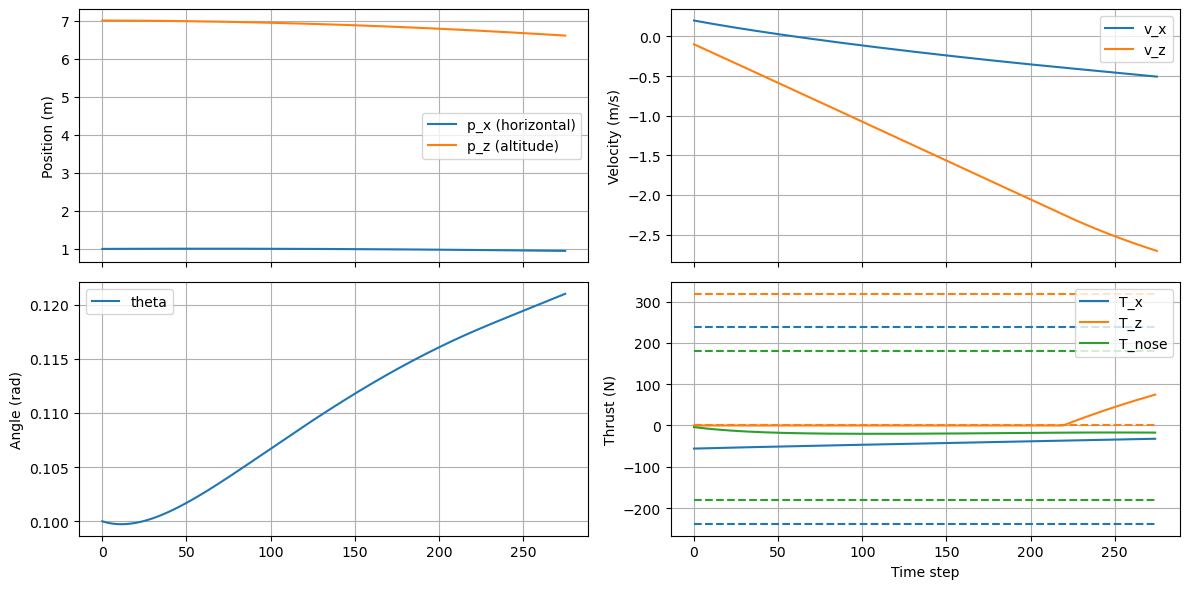

In [621]:
target_state = jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # target state
# gains = jnp.array(
#     [50.0, 30.0, 50.0, 150.0, 90.0, 100.0]
# )  # gains for the PD controller; feel free to adjust these

gains = {
    "Kp_x": 50.0,
    "Kd_x": 30.0,
    "Kp_z": 50.0,
    "Kd_z": 150.0,
    "Kp_theta": 90.0,
    "Kd_theta": 100.0,
}

# set up the PD controller. Use functools.partial to fix the target, gains, and limits
controller = functools.partial(
    PD_controller, target=target_state, gains=gains, limits=limits
)

initial_state = jnp.array(
    [1.0, 7.0, 0.1, 0.2, -0.1, -0.05]
)  # initial state; feel free to adjust this
n_steps = 275  # number of steps; feel free to adjust this
states, controls = closed_loop_sim(
    rocket_dt, initial_state, controller, n_steps
)  # simulate the dynamics given a closed-loop controller

# plot the trajectory
plot_rocket_trajectory(states, controls, lower, upper)

In [622]:
# animate the trajectory. This takes a few seconds to run.
animate_rocket_trajectory(states, controls, thrust_limit=upper)

### (c) Land the rocket with SQP!

You may have noticed that tuning a good set of PD gains can be difficult, and even an effective gain set may only succeed for some initial conditions. The challenge of reliably landing the rocket motivates a more systematic approach.
Trajectory optimization allows us to compute the most efficient sequence of controls and states, while explicitly enforcing constraints to prevent the rocket from crashing and to satisfy other requirements.

Specifically, we aim to find a sequence of states $\{x_0, x_1, \ldots, x_N\}$ and controls $\{u_0, u_1, \ldots, u_{N-1}\}$ that minimizes the total weighted state and control effort, subject to the rocket ending at the origin (both in position, velocity, and angle), obeying the system dynamics, and respecting input limits:

$$
\begin{align*}
\text{minimize}_{x_{0:N},\, u_{0:N-1}} \quad & \sum_{k=0}^{N-1} x_k^\top Q x_k + u_k^\top R u_k \\
\text{subject to} \quad
     & x_{k+1} = f(x_k, u_k), \quad\;\; k = 0, \ldots, N-1 \\
     & x_0 = x_\text{init} \\
     & x_N = x_\text{target} \\
     & p_{z,k} \geq 0, \qquad k = 0, \ldots, N\\
     & u_\text{min} \leq u_k \leq u_\text{max}, \qquad k = 0, \ldots, N-1 \\
\end{align*}
$$

Here, $x_k$ is the full rocket state at step $k$, and $u_k$ is the control input at step $k$.
However, because the dynamics $f(x, u)$ are highly nonlinear, directly solving this optimization is extremely challenging.
In the next steps, you will implement the essential components for solving this problem via Sequential Quadratic Programming (SQP).


#### (i) Linearize dynamics

Notice in the trajectory optimization problem above that the objective is quadratic, and all constraints except for the dynamics are linear. This means the problem is almost a quadratic program (QP)!

To fully convert it into a QP, we need to linearize the dynamics constraint.

Implement the following function, which outputs $A$, $B$, and $C$ satisfying $\dot{x} \approx Ax + Bu + C$ at a chosen operating point.

*Hint: You may find it useful to revisit notebook 1b for inspiration.*

In [623]:
@eqx.filter_jit
def linearize_dynamics(
    dynamics: Callable[[jnp.ndarray, jnp.ndarray], jnp.ndarray],
    state: jnp.ndarray,
    control: jnp.ndarray,
    time: float = 0.0,
):
    """Linearize dynamics around the given state and control.

    Args:
        dynamics: Function(state, control, timestep) -> next_state
        state: (n,) array of state around which to linearize
        control: (m,) array of control around which to linearize
        time: float, time at which to linearize, in case dynamics are time-varying

    Returns:
        A: State transition matrix (n, n)
        B: Control input matrix (n, m)
        C: Constant term (n,)
    """

    # TODO: Implement the linearization here
    ###### add your code here
    # A, B = jax.jacobian(dynamics, argnums=(0, 1))(
    #     state, control, time
    # )  # one line but less readable imo
    J_x = jax.jacobian(dynamics, 0) # wrt state
    J_u = jax.jacobian(dynamics, 1) # wrt control
    A = J_x(state, control, time)
    B = J_u(state, control, time)
    C = dynamics(state, control, time) - (
        A @ state + B @ control
    )  # evaluate dynamics to get constant term
    return A, B, C
    ###### end of add your code here


Next, let's linearize the dynamics along the state and control trajectory produced by your PD controller.
This process will yield linear, time-varying dynamics of the form:
$$
x_{k+1} = A_k x_k + B_k u_k + C_k
$$
where $A_k$, $B_k$, and $C_k$ are computed at each timestep $k$ along the trajectory.

These matrices capture the local, linear approximation of the true nonlinear dynamics at each point in time along the trajectory.
Thus, the system is described by *time-varying* linear dynamics.

To efficiently compute $A_k$, $B_k$, and $C_k$ for all timesteps, apply `jax.vmap` to `linearize_dynamics`.

In [624]:
states, controls = closed_loop_sim(rocket_dt, initial_state, controller, n_steps)

# TODO: linearize the dynamics about the trajectory
###### add your code here
As, Bs, Cs = jax.vmap(linearize_dynamics, in_axes=(None, 0, 0))(
    rocket_dt, states[:-1], controls
)
###### end of add your code here


#### (ii) Set up and solve the CVXPY problem
Having linearized the dynamics around a given trajectory, we can now formulate and solve a trajectory optimization problem using this linearized system.

The locally linearized, discrete-time dynamics are given by:

$$
\begin{align*}
x_{k+1} &= A_k x_k + B_k u_k + C_k, \qquad k = 0, ..., N-1 \\
\end{align*}
$$

where $A_k$, $B_k$, $C_k$ are the time-varying linearization matrices about $(\tilde{x}_k, \tilde{u}_k)$.

For the linearized system, we formulate the following quadratic program (QP):

$$
\begin{align*}
\underset{x_{0:N},\ u_{0:N-1}}{\text{minimize}} \quad
    & \sum_{k=0}^{N-1} \left(
        x_k^\top Q x_k
        + u_k^\top R u_k
        + (x_k - \tilde{x}_k)^\top Q_\mathrm{trp} (x_k - \tilde{x}_k)
        + (u_k - \tilde{u}_k)^\top R_\mathrm{trp} (u_k - \tilde{u}_k)
      \right) \\
    &\quad + (x_N - x_\mathrm{target})^\top Q_N (x_N - x_\mathrm{target}) \\
\text{subject to} \qquad
    & x_{k+1} = A_k x_k + B_k u_k + C_k, \quad   k = 0, ..., N-1 \\
    & x_0 = x_\mathrm{init} \\
    & p_{z,k} \geq 0, \qquad k = 0, \ldots, N\\
    & u_{\min} \leq u_k \leq u_{\max}, \qquad k = 0, ..., N-1 \\
\end{align*}
$$

Here, the matrices $Q_\mathrm{trp}$ and $R_\mathrm{trp}$ impose a *trust region penalty*, encouraging the optimized trajectory $(x_k, u_k)$ to stay close to the trajectory $(\tilde{x}_k, \tilde{u}_k)$ about which the dynamics were linearized. This is important because the quality of the linear approximation degrades further from the linearization points.
Rather than enforcing a hard terminal state constraint (which might be infeasible for a given horizon or control limits), we use a large terminal cost via $Q_N$ to softly encourage the final state to reach the desired target.
With these design choices, the problem becomes a convex quadratic program (QP) which we can efficiently solve using `cvxpy`.

Set up the corresponding `cvxpy` problem as described above.

In [625]:
state_dim = rocket_ct.state_dim  # 6, state dimension
control_dim = rocket_ct.control_dim  # 3, control dimension
n_steps = 3000  # feel free to adjust number of steps.

# set up the cost matrices. Feel free to adjust these to see how they affect the optimization.
#Q = cp.Parameter((state_dim, state_dim), name="Q", PSD=True)
# encourage the rocket to stay upright and slow; state: [p_x, p_z, theta, v_x, v_z, omega]

#R = cp.Parameter((control_dim, control_dim), name="R", PSD=True)
# control cost matrix; control: [T_x, T_z, T_theta]

#QN = cp.Parameter((state_dim, state_dim), name="QN", PSD=True)
# terminal cost matrix; state: [p_x, p_z, theta, v_x, v_z, omega

#QTRP = cp.Parameter((state_dim, state_dim), name="QTRP", PSD=True)
# trust region penalty for state deviations.

#RTRP = cp.Parameter((control_dim, control_dim), name="RTRP", PSD=True)


# adjust cost matrices and resolve
Q = cp.Constant(
    np.diag([1.0, 0, 1000.0, 0.5, 0.5, 500.0])
)  # encourage the rocket to stay upright and slow; state: [p_x, p_z, theta, v_x, v_z, omega]
R = cp.Constant(
    np.diag([0.0001, 0.0001, 0.00])
)  # control cost matrix; control: [T_x, T_z, T_theta]
QN = cp.Constant(
    np.diag([100.0, 500.0, 200000.0, 1000.0, 800.0, 100000.0])
)  # terminal cost matrix; state: [p_x, p_z, theta, v_x, v_z, omega
QTRP = cp.Constant(
    np.diag([10.0, 10.0, 500.0, 10.0, 10.0, 500.0])
)  # trust region penalty for state deviations.
RTRP = cp.Constant(
    np.eye(control_dim) * 10.0
)  # trust region penalty for control deviations.
# trust region penalty for control deviations.

In [626]:
# set up cvxpy optimization variables
states = cp.Variable(
    (n_steps + 1, state_dim)
)  # state trajectory [n_steps+1, state_dim]
controls = cp.Variable(
    (n_steps, control_dim)
)  # control trajectory [n_steps, control_dim]

# set up the A, B, C matrices as parameters since they will be updated at each SQP iteration
As = cp.Parameter((n_steps, state_dim, state_dim), name="As")
Bs = cp.Parameter((n_steps, state_dim, control_dim), name="Bs")
Cs = cp.Parameter((n_steps, state_dim), name="Cs")

# set up the previous state and control parameters since they will be updated at each SQP iteration
previous_states = cp.Parameter((n_steps + 1, state_dim), name="previous_states")
previous_controls = cp.Parameter((n_steps, control_dim), name="previous_controls")

# set up the goal state as a parameter in case you want to change the goal state later on
target_state = cp.Parameter((state_dim), name="target_state")

# set up the initial state parameter in case you want to change the initial state later on
initial_state = cp.Parameter(state_dim, name="initial_state")

# set up control constraints
u_min = cp.Constant(lower, name="u_min")
u_max = cp.Constant(upper, name="u_max")

# TODO: set up the objective and constraints here
###### add your code here
# calculate state and control deviations from the last solution for trust region penalty
state_deviation = states - previous_states
control_deviation = controls - previous_controls
terminal_state_error = states[-1] - target_state

objective = cp.sum(
    [cp.quad_form(states[k], Q) for k in range(n_steps)]
    + [cp.quad_form(controls[k], R) for k in range(n_steps)]
    + [cp.quad_form(state_deviation[k], QTRP) for k in range(n_steps + 1)]
    + [cp.quad_form(control_deviation[k], RTRP) for k in range(n_steps)]
    + [cp.quad_form(terminal_state_error, QN)]
)

# constraints
dynamics_constraint = [
    states[k + 1] == As[k] @ states[k] + Bs[k] @ controls[k] + Cs[k]
    for k in range(n_steps)
]
initial_cond = states[0, :] == initial_state

THETA_LIMIT = 1.0  # rad
# tried to add this constraint but the solver failed: cp.abs(states[:, 2]) <= THETA_LIMIT
state_constraints = [
    states[:, 1] >= 0,  # stay above ground
    states[:, 2] <= THETA_LIMIT,  # don't flip
    states[:, 2] >= -THETA_LIMIT,
]  # don't flip the other way either
control_constraints = [
    controls >= u_min,
    controls <= u_max,
]  # constrains all controls at all times
constraints = [
    *dynamics_constraint,
    initial_cond,
    *state_constraints,
    *control_constraints,
]
###### end of add your code here

problem = cp.Problem(cp.Minimize(objective), constraints)


/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/problems/problem.py:167: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


Now, compute and set the values for the Parameters and solve!

In [ ]:
# target state value
target_state_value = np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
)  # feel free to adjust target state

# initial state value
initial_state_value = np.array(
    [1.0, 7.0, 0.1, 0.2, -0.1, -0.05]
)  # feel free to adjust initial state

# previous states and controls values using the outputs of the PD controller
previous_states_values, previous_controls_values = closed_loop_sim(
    rocket_dt, initial_state_value, controller, n_steps
)

# linearize the dynamics about the previous states and controls

linearize_trajectory = jax.vmap(linearize_dynamics, in_axes=(None, 0, 0))
As_values, Bs_values, Cs_values = linearize_trajectory(
    rocket_dt, previous_states_values[:-1], previous_controls_values
)
# As_values, Bs_values, Cs_values = jax.vmap(linearize_dynamics, in_axes=(None, 0, 0))(
#     rocket_dt, previous_states_values[:-1], previous_controls_values
# )


: 

In [ ]:
# set the values for the parameters. Convert to numpy array to avoid issues with cvxpy.
As.value = np.array(As_values)
Bs.value = np.array(Bs_values)
Cs.value = np.array(Cs_values)

previous_states.value = np.array(previous_states_values)
previous_controls.value = np.array(previous_controls_values)

target_state.value = target_state_value
initial_state.value = initial_state_value

# solve the problem
problem.solve(solver=cp.CLARABEL)
print(f"Cost: {problem.value}")
print(f"Status: {problem.status}")

/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:251: UserWarning: Your problem has too many parameters for efficient DPP compilation. We suggest setting 'ignore_dpp = True'.
  warnings.warn(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/problems/problem.py:167: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


In [ ]:
solver_states = states.value
plot_rocket_trajectory(states.value, controls.value, lower, upper)

In [ ]:
# compute states with true nonlinear dynamics. Recall that states.value is the optimized trajectory based on linearized dynamics.
open_loop_states = open_loop_sim(rocket_dt, initial_state_value, controls.value)

In [ ]:
plot_rocket_trajectory(open_loop_states, controls.value, lower, upper)

In [ ]:
animate_rocket_trajectory(open_loop_states, controls.value, thrust_limit=upper)

#### (iii) Perform Sequential Quadratic Programming (SQP) Iterations
So far, you have completed a single SQP iteration. The power of SQP comes from repeating this process:
linearizing around the current trajectory, solving the optimization, and then updating the trajectory based on the new solution.

Implement a loop to carry out multiple SQP iterations. After each iteration, use the latest solution (states/controls) as the new nominal trajectory about which to linearize for the next step. Continue this process to progressively improve the trajectory.

In [ ]:
# setting up the problem again

# target state value
target_state_value = np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
)  # feel free to adjust target state

# initial state value
initial_state_value = np.array(
    [1.0, 7.0, 0.1, 0.2, -0.1, -0.05]
)  # feel free to adjust initial state

# previous states and controls values using the outputs of the PD controller
previous_states_values, previous_controls_values = closed_loop_sim(
    rocket_dt, initial_state_value, controller, n_steps
)

# set the values for the parameters.
target_state.value = target_state_value
initial_state.value = initial_state_value

In [ ]:
n_SQP_iterations = 10  # 50  # feel free to adjust number of SQP iterations
controls_list = [previous_controls_values]  # list of controls to collect for plotting
costs = []  # list of costs to collect for plotting

# loop through SQP iterations
for i in range(n_SQP_iterations):
    # TODO: implement SQP iteration here
    ###### add your code here

    # initialize/update previous trajectory & controls
    # convert to numpy array bc jax arrays don't work as cvxpy variables
    previous_states.value = np.array(previous_states_values)
    previous_controls.value = np.array(previous_controls_values)

    # linearize about previous trajectory & controls
    As_values, Bs_values, Cs_values = linearize_trajectory(
        rocket_dt, previous_states_values[:-1], previous_controls_values
    )
    # update cvxpy parmaeters with new linearized system matrices
    As.value = np.array(As_values)
    Bs.value = np.array(Bs_values)
    Cs.value = np.array(Cs_values)

    # solve for the optimal trajectory & controls
    problem.solve()

    print(f"SQP iteration {i + 1}/{n_SQP_iterations} complete... Cost: {problem.value}")

    # update previous states and controls...
    # cannot combine these lines with updating the .value because
    # the first previous_states and previous_controls comes from
    # the closed loop simulation (not optimizaiton)
    previous_states_values = jnp.array(states.value)
    previous_controls_values = jnp.array(controls.value)

    # collect cost and control sequence
    costs.append(problem.value)
    controls_list.append(controls.value)

    ###### end of add your code here


controls_list = np.array(controls_list)

# with the collected controls, compute the states with true nonlinear dynamics.
# Recall that states.value is the optimized trajectory based on linearized dynamics, so they don't match the true nonlinear dynamics.
states_list = jax.vmap(open_loop_sim, in_axes=(None, None, 0))(
    rocket_dt, initial_state_value, controls_list
)

In [ ]:
# plot all the trajectories for each SQP iteration
plot_rocket_trajectory(states_list, controls_list, lower, upper)

In [ ]:
# plot the last trajectory from the SQP iterations
plot_rocket_trajectory(states_list[-1], controls_list[-1], lower, upper)

In [ ]:
# animate the last trajectory from the SQP iterations
animate_rocket_trajectory(states_list[-1], controls_list[-1], thrust_limit=upper)

#### (iv) Add obstacle constraints

Suppose that there is a circular obstacle located at $(x_0, z_0)$ with radius $r$ that the rocket needs to avoid. The constraint is
$$
g(x= [p_x, p_z, \theta, \dot{p}_x, \dot{p}_x, \dot{\theta}]^T) = r^2 - (p_x - x_0)^2 - (p_z - z_0)^2  \leq 0
$$
We require this constraint to be satisfied at every time step along the trajectory.
This is a nonlinear, non-convex constraint. Like what we did with the dynamics, we can also linearize the obstacle constraint about a state $\tilde{x}_k$

$$
g(x_k) \approx g(\tilde{x}_k) + \nabla g(\tilde{x}_k)^T(x_k - \tilde{x}_k) = G_kx_k + h_k
$$

Thus the QP problem we wish to solve at each SQP iteration becomes

$$
\begin{align*}
\text{minimize}_{x_{0:N}, u_{0:N-1}} \ & \left[\sum_{k=0}^{N-1} x_k^TQx_k + u_k^TRu_k + (x_k - \tilde{x}_k)^TQ_\text{tpr}(x_k - \tilde{x}_k) + (u_k - \tilde{u}_k)^TR_\text{tpr}(u_k - \tilde{u}_k) \right]  + (x_N - x_{\text{target}})^T Q_N (x_N - x_{\text{target}}) \\
\text{subject to} \quad
& x_{k+1} = A_k x_k + B_k u_k + C_k, \qquad k = 0, ..., N-1 \\
& x_0 = x_{\text{init}} \\
& p_{z,k} \geq 0, \qquad k = 0, \ldots, N\\
& G_kx_k + h_k \leq 0 \\
& u_{\text{min}} \leq u_k \leq u_{\text{max}}, \qquad k = 0, ..., N-1 \\
\end{align*}
$$


Copy your `cvxpy` problem developed the the previous part and modify it here to include the linearized obstacle constraint. Then run multiple SQP iterations.


In [ ]:
# obstacle constraint function
def circular_obstacle_constraint(
    state: jnp.ndarray, obs_center: jnp.ndarray, obs_radius: float
) -> jnp.ndarray:
    """Compute obstacle constraint value"""
    p_x, p_z = state[0], state[1]
    obs_x, obs_z = obs_center
    dist_sq = (p_x - obs_x) ** 2 + (p_z - obs_z) ** 2
    return obs_radius**2 - dist_sq


In [ ]:
state_dim = rocket_ct.state_dim  # 6, state dimension
control_dim = rocket_ct.control_dim  # 3, control dimension
n_steps = 300  # feel free to adjust number of steps.

# set up the cost matrices. Feel free to adjust these to see how they affect the optimization.
Q = cp.Constant(
    np.diag([1.0, 0, 20.0, 0.5, 0.5, 10.0]), name="state_cost"
)  # encourage the rocket to stay upright and slow
R = cp.Constant(
    np.diag([0.005, 0.001, 0.00]), name="control_cost"
)  # control cost matrix.
QN = cp.Constant(
    np.diag([100.0, 500.0, 1000.0, 1000.0, 800.0, 1000.0]) * 100, name="terminal_cost"
)  # terminal cost matrix.
QTRP = cp.Constant(
    np.eye(state_dim) * 5.0, name="state_trust_region_penalty"
)  # trust region penalty for state deviations.
RTRP = cp.Constant(
    np.eye(control_dim) * 5.0, name="control_trust_region_penalty"
)  # trust region penalty for control deviations.


In [ ]:
# TODO: copy your cvxpy problem from (ii) and make the necessary modifications to account for the obstacles.
###### add your code here
# objective = ...
# constraints = ...
###### end of add your code here


problem = cp.Problem(cp.Minimize(objective), constraints)


In [ ]:
# setting up the problem again

# target state value
target_state_value = np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
)  # feel free to adjust target state

# choose obstacle center and radius
obstacle_center_value = np.array([-0.01, 4.0])  # feel free to adjust obstacle center
obstacle_radius_value = np.array(0.5)  # feel free to adjust obstacle radius

# obstacle constraint function. Use functools.partial to fix the obstacle center and radius.
obstacle_constraint = functools.partial(
    circular_obstacle_constraint,
    obs_center=obstacle_center_value,
    obs_radius=obstacle_radius_value,
)

# initial state value
initial_state_value = np.array([0.2, 7.0, 0.1, 0.2, -0.1, -0.05])

# previous states and controls values using the outputs of the PD controller
previous_states_values, previous_controls_values = closed_loop_sim(
    rocket_dt, initial_state_value, controller, n_steps
)


target_state.value = target_state_value
initial_state.value = initial_state_value

# update the obstacle center and radius
obstacle_center.value = obstacle_center_value
obstacle_radius.value = obstacle_radius_value


In [ ]:
# TODO: copy your code from (iii) and make the necessary modifications to account for the obstacles.
###### add your code here
# SQP loop ...
# controls_list = []
# collect control sequence
###### end of add your code here


# compute states with true nonlinear dynamics. Recall that states.value is the optimized trajectory based on linearized dynamics.
states_list = jax.vmap(open_loop_sim, in_axes=(None, None, 0))(
    rocket_dt, initial_state_value, controls_list
)

In [ ]:
plot_rocket_trajectory(states_list, controls_list, lower, upper)

In [ ]:
plot_rocket_trajectory(states_list[-1], controls_list[-1], lower, upper)

In [ ]:
animate_rocket_trajectory(
    states_list[-1],
    controls_list[-1],
    obstacle_center=obstacle_center_value,
    obstacle_radius=obstacle_radius_value,
    thrust_limit=upper,
)

Congratulations! You have just performed SQP on a rocket landing problem!
Here are some ideas that may inspire your project, or just something fun for you to try in your spare time:
- Try with more interesting problem settings, like trying to swing up the rocket from a hanging orientation to an upright position.
- Learn a model to produce good warmstarts for the trajectory optimizer
- Improve the trajectory optimizer to be robust to wind disturbances
- Using a more complex rocket model.
- Incorporate more complex constraints, like state-triggered constraints, signal temporal logic constraints, state-dependent control constraints.
- Apply CBF / CLF filters

In [ ]:
state_dim = rocket_ct.state_dim  # 6, state dimension
control_dim = rocket_ct.control_dim  # 3, control dimension
n_steps = 300  # feel free to adjust number of steps.

# set up the cost matrices. Feel free to adjust these to see how they affect the optimization.
Q = cp.Constant(
    np.diag([1.0, 0, 20.0, 0.5, 0.5, 10.0]), name="state_cost"
)  # encourage the rocket to stay upright and slow
R = cp.Constant(
    np.diag([0.005, 0.001, 0.00]), name="control_cost"
)  # control cost matrix.
QN = cp.Constant(
    np.diag([100.0, 500.0, 1000.0, 1000.0, 800.0, 1000.0]) * 100, name="terminal_cost"
)  # terminal cost matrix.
QTRP = cp.Constant(
    np.eye(state_dim) * 10.0, name="state_trust_region_penalty"
)  # trust region penalty for state deviations.
RTRP = cp.Constant(
    np.eye(control_dim) * 10.0, name="control_trust_region_penalty"
)  # trust region penalty for control deviations.

slack_penalty = cp.Constant(100000.0, name="slack_penalty")

In [ ]:
# TODO: copy your cvxpy problem from (ii) and make the necessary modifications to account for the obstacles.
###### add your code here
# objective = ...
# constraints = ...
###### end of add your code here


problem = cp.Problem(cp.Minimize(objective), constraints)


In [ ]:
# setting up the problem again

# target state value
target_state_value = np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
)  # feel free to adjust target state

# choose obstacle center and radius
obstacle_center_value = np.array([-0.01, 4.0])  # feel free to adjust obstacle center
obstacle_radius_value = np.array(0.5)  # feel free to adjust obstacle radius

# obstacle constraint function. Use functools.partial to fix the obstacle center and radius.
obstacle_constraint = functools.partial(
    circular_obstacle_constraint,
    obs_center=obstacle_center_value,
    obs_radius=obstacle_radius_value,
)

# initial state value
initial_state_value = np.array([0.1, 8.0, 0.1, -0.1, -0.1, -0.05])

# previous states and controls values using the outputs of the PD controller
previous_states_values, previous_controls_values = closed_loop_sim(
    rocket_dt, initial_state_value, controller, n_steps
)
previous_controls_values = np.zeros([n_steps, control_dim])
previous_states_values = open_loop_sim(
    rocket_dt, initial_state_value, previous_controls_values
)

target_state.value = target_state_value
initial_state.value = initial_state_value

# update the obstacle center and radius
obstacle_center.value = obstacle_center_value
obstacle_radius.value = obstacle_radius_value


In [ ]:
# TODO: copy your code from (iii) and make the necessary modifications to account for the obstacles.
###### add your code here
# SQP loop ...
# controls_list = []
# collect control sequence
###### end of add your code here


# compute states with true nonlinear dynamics. Recall that states.value is the optimized trajectory based on linearized dynamics.
states_list = jax.vmap(open_loop_sim, in_axes=(None, None, 0))(
    rocket_dt, initial_state_value, controls_list
)

In [ ]:
plot_rocket_trajectory(states_list, controls_list, lower, upper)

In [ ]:
plot_rocket_trajectory(states_list[-1], controls_list[-1], lower, upper)

In [ ]:
animate_rocket_trajectory(
    states_list[-1],
    controls_list[-1],
    obstacle_center=obstacle_center_value,
    obstacle_radius=obstacle_radius_value,
    thrust_limit=upper,
)